# CloudPlay A/B Test Analysis

## Experiment background

Previous funnel analysis showed that 23.08% of product journeys did not result
in a gaming session.

The product team wants to test whether a redesigned game discovery experience
can help users find a game and start playing more successfully.

## Experiment design

**Control (A):**
Current game discovery experience.

**Treatment (B):**
Redesigned game discovery experience with improved game recommendations.

**Primary metric:**
Conversion to gaming session.

A user is considered converted if they start at least one gaming session
during the experiment.

**Null hypothesis (H0):**
The gaming session conversion rate is the same for the control and treatment groups.

**Alternative hypothesis (H1):**
The gaming session conversion rate differs between the control and treatment groups.

## 1. Setup

This notebook uses Python for experiment simulation and statistical analysis.

The experiment is synthetic and was designed as an extension of the CloudPlay
product analysis performed in PostgreSQL.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chisquare, ttest_ind

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    proportion_effectsize,
    proportions_ztest,
    confint_proportions_2indep
)
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW

## 2. Sample Size and Power Analysis

Before running the experiment, the required sample size was estimated.

The historical baseline conversion rate from product journey to gaming session
was **76.92%**.

The experiment was designed to detect a minimum absolute improvement of
**1 percentage point**, corresponding to a target conversion rate of **77.92%**.

Experiment parameters:

- Baseline conversion: **76.92%**
- Minimum Detectable Effect (MDE): **+1.00 percentage point**
- Significance level (α): **0.05**
- Statistical power: **80%**
- Allocation ratio: **50/50**

Cohen's h is used as the effect size for the comparison of two proportions.

In [4]:
baseline_conversion = 0.7692
target_conversion = 0.7792

effect_size = proportion_effectsize(baseline_conversion, target_conversion)
print(effect_size)

-0.023918567138126345


In [6]:
effect_size=abs(effect_size)
analysis = NormalIndPower()
sample_size=analysis.solve_power(effect_size, power=0.80, alpha=0.05, ratio=1.0)
sample_size=int(np.ceil(sample_size))
print(sample_size)

27439


### Sample size result

The experiment requires approximately **27,439 users per group**, or
**54,878 users in total**, to detect the predefined MDE with 80% statistical power.

## 3. Synthetic Experiment Simulation

Users are assigned to two equally sized experiment groups:

- **Control (A):** current game discovery experience
- **Treatment (B):** redesigned game discovery experience

For simulation purposes, the underlying conversion probabilities are set to:

- Control: **76.92%**
- Treatment: **78.20%**

These probabilities are parameters of the synthetic data generator. The analysis
below uses the observed experiment outcomes rather than assuming these exact
conversion rates.

In [7]:
control_conversion = 0.7692
treatment_conversion = 0.7820

np.random.seed(42)

experiment = pd.DataFrame({
    'user_id': np.arange(1, sample_size * 2 + 1),
    'group': np.repeat(['A', 'B'], sample_size)
})

experiment['converted'] = np.where(
    experiment['group'] == 'A',
    np.random.binomial(1, control_conversion, len(experiment)),
    np.random.binomial(1, treatment_conversion, len(experiment))
)

print(experiment.head())

print('\nGroup sizes:')
print(experiment['group'].value_counts())

print('\nObserved conversion:')
print(experiment.groupby('group')['converted'].mean())

   user_id group  converted
0        1     A          1
1        2     A          0
2        3     A          1
3        4     A          1
4        5     A          1

Group sizes:
group
A    27439
B    27439
Name: count, dtype: int64

Observed conversion:
group
A    0.769161
B    0.781989
Name: converted, dtype: float64


## 4. Primary Metric Analysis

The primary metric is **conversion to a gaming session**.

The treatment effect is evaluated using:

- observed conversion rates;
- absolute uplift;
- relative uplift;
- two-proportion z-test;
- 95% confidence interval for the difference in conversion rates.

In [9]:
conversion = experiment.groupby('group')['converted'].mean()

control_rate = conversion['A']
treatment_rate = conversion['B']

absolute_uplift = treatment_rate - control_rate
relative_uplift = absolute_uplift / control_rate

print(f'Control conversion: {control_rate:.2%}')
print(f'Treatment conversion: {treatment_rate:.2%}')
print(f'Absolute uplift: {absolute_uplift:.2%}')
print(f'Relative uplift: {relative_uplift:.2%}')

Control conversion: 76.92%
Treatment conversion: 78.20%
Absolute uplift: 1.28%
Relative uplift: 1.67%


The treatment group achieved a higher observed conversion rate than the control
group, with an absolute uplift of approximately **1.28 percentage points**.

### Statistical significance

The hypotheses are:

**H₀:** The conversion rate is equal between the control and treatment groups.

**H₁:** The conversion rate differs between the control and treatment groups.

A two-proportion z-test is used with a significance level of α = 0.05.

In [11]:
conversions = experiment.groupby('group')['converted'].sum()

users = experiment.groupby('group')['converted'].count()

z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=users
)

print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value: {p_value:.6f}')

Z-statistic: -3.6016
P-value: 0.000316


The p-value (**0.000316**) is below the predefined significance level of 0.05.

Therefore, the null hypothesis is rejected, providing evidence of a statistically
significant difference in conversion rates between the experiment groups.

### Effect uncertainty

Statistical significance alone does not describe the magnitude or uncertainty
of the treatment effect.

A 95% confidence interval is therefore calculated for the absolute difference
between treatment and control conversion rates.

In [14]:
control_conversions = experiment.loc[
    experiment['group'] == 'A', 'converted'
].sum()

treatment_conversions = experiment.loc[
    experiment['group'] == 'B', 'converted'
].sum()

control_users = (experiment['group'] == 'A').sum()
treatment_users = (experiment['group'] == 'B').sum()

ci_lower, ci_upper = confint_proportions_2indep(
    count1=treatment_conversions,
    nobs1=treatment_users,
    count2=control_conversions,
    nobs2=control_users,
    method='wald',
    compare='diff',
    alpha=0.05
)

print(f'Observed uplift: {absolute_uplift:.2%}')
print(f'95% CI: [{ci_lower:.2%}, {ci_upper:.2%}]')

Observed uplift: 1.28%
95% CI: [0.58%, 1.98%]


The observed uplift is approximately **+1.28 percentage points**, with a
95% confidence interval of **[+0.58 pp, +1.98 pp]**.

The interval does not include zero, supporting a positive treatment effect.

However, the confidence interval includes the predefined MDE of +1.00 percentage
point. Therefore, while the experiment provides evidence that the treatment
improves conversion, the data do not establish with 95% confidence that the
true improvement is at least the full predefined MDE.

## 5. Sample Ratio Mismatch Check

Before interpreting the experiment results, the observed group allocation is
checked against the planned 50/50 split.

A chi-square goodness-of-fit test is used to detect a potential Sample Ratio
Mismatch (SRM).

**H₀:** Users are allocated according to the expected 50/50 ratio.

**H₁:** The observed allocation differs from the expected ratio.

In [16]:
group_counts = experiment['group'].value_counts().sort_index()

expected_counts = np.array([
    len(experiment) / 2,
    len(experiment) / 2
])

chi2_stat, srm_p_value = chisquare(
    f_obs=group_counts.values,
    f_exp=expected_counts
)

print('Observed group sizes:')
print(group_counts)

print(f'\nSRM chi-square: {chi2_stat:.4f}')
print(f'SRM p-value: {srm_p_value:.4f}')

Observed group sizes:
group
A    27439
B    27439
Name: count, dtype: int64

SRM chi-square: 0.0000
SRM p-value: 1.0000


Both groups contain exactly **27,439 users**, producing an SRM p-value of **1.00**.

There is no evidence of Sample Ratio Mismatch.

Because this is a synthetic experiment with balanced allocation by design,
this check is included to demonstrate the standard experiment validation workflow.

## 6. Guardrail Metric: Session Duration

Improving conversion is valuable only if the redesigned experience does not
meaningfully degrade subsequent user engagement.

Average session duration among converted users is therefore used as a guardrail
metric.

The synthetic session-duration data are generated from the same underlying
distribution for both experiment groups, representing a scenario where the
treatment affects conversion but does not intentionally affect post-conversion
engagement.

In [17]:
converted_mask = experiment['converted'] == 1

experiment['session_duration'] = np.nan

experiment.loc[converted_mask, 'session_duration'] = np.random.lognormal(
    mean=np.log(52),
    sigma=0.45,
    size=converted_mask.sum()
)

session_summary = (
    experiment[experiment['converted'] == 1]
    .groupby('group')['session_duration']
    .agg(['count', 'mean', 'median', 'std'])
)

print(session_summary)

       count       mean     median        std
group                                        
A      21105  57.551384  52.022583  27.294421
B      21457  57.562562  52.072622  27.245456


### Distribution analysis

Session duration is a positive, right-skewed metric. Its distribution is inspected
before comparing the experiment groups.

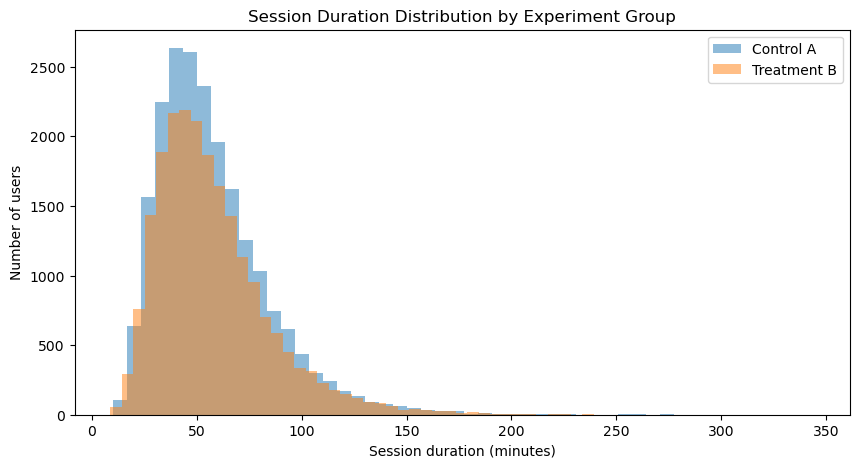

In [18]:
control_duration = experiment.loc[
    (experiment['group'] == 'A') &
    (experiment['converted'] == 1),
    'session_duration'
]

treatment_duration = experiment.loc[
    (experiment['group'] == 'B') &
    (experiment['converted'] == 1),
    'session_duration'
]

plt.figure(figsize=(10, 5))

plt.hist(
    control_duration,
    bins=50,
    alpha=0.5,
    label='Control A'
)

plt.hist(
    treatment_duration,
    bins=50,
    alpha=0.5,
    label='Treatment B'
)

plt.xlabel('Session duration (minutes)')
plt.ylabel('Number of users')
plt.title('Session Duration Distribution by Experiment Group')
plt.legend()

plt.show()

Both groups show strongly overlapping right-skewed distributions.

Because the analysis compares mean session duration and both groups contain more
than 20,000 observations, Welch's t-test is used. This version of the t-test does
not assume equal variances between groups.

In [20]:
t_stat, p_value_duration = ttest_ind(
    treatment_duration,
    control_duration,
    equal_var=False
)

mean_control = control_duration.mean()
mean_treatment = treatment_duration.mean()
mean_difference = mean_treatment - mean_control

print(f'Control mean: {mean_control:.2f} min')
print(f'Treatment mean: {mean_treatment:.2f} min')
print(f'Mean difference: {mean_difference:.2f} min')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value_duration:.4f}')

Control mean: 57.55 min
Treatment mean: 57.56 min
Mean difference: 0.01 min
T-statistic: 0.0423
P-value: 0.9663


The observed mean session duration is:

- Control: **57.55 minutes**
- Treatment: **57.56 minutes**
- Difference: **+0.01 minutes**

The Welch's t-test produces a p-value of **0.9663**, providing no evidence of
a difference in mean session duration between the groups.

However, failure to detect a difference does not by itself demonstrate that the
treatment is non-inferior.

### Guardrail non-inferiority assessment

A maximum acceptable degradation of **2 minutes** is defined for average session
duration.

The non-inferiority margin is therefore:

**Δ = -2 minutes**

The treatment is considered non-inferior if the lower confidence bound for
the difference (Treatment − Control) remains above -2 minutes.

In [22]:
control_stats = DescrStatsW(control_duration)
treatment_stats = DescrStatsW(treatment_duration)

comparison = CompareMeans(
    treatment_stats,
    control_stats
)

ci_lower, ci_upper = comparison.tconfint_diff(
    alpha=0.05,
    usevar='unequal'
)

print(f'Mean difference: {mean_difference:.2f} min')
print(f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}] min')

Mean difference: 0.01 min
95% CI: [-0.51, 0.53] min


The estimated difference is **+0.01 minutes**, with a 95% confidence interval
of **[-0.51, +0.53] minutes**.

The lower confidence bound (-0.51 minutes) remains above the predefined
non-inferiority margin of -2 minutes.

The results therefore support that the treatment does not cause a practically
meaningful degradation in average session duration under the predefined margin.

## 7. Experiment Conclusion

In the simulated experiment, the redesigned game discovery experience increased observed conversion to a gaming session from approximately **76.92%** to **78.20%**, corresponding to an uplift of **+1.28 percentage points**.

The difference was statistically significant (**p = 0.000316**), and the 95%
confidence interval for the treatment effect was **[+0.58 pp, +1.98 pp]**.

No Sample Ratio Mismatch was detected.

The guardrail analysis found no meaningful degradation in average session duration.
The estimated difference was **+0.01 minutes**, with a 95% confidence interval
of **[-0.51, +0.53] minutes**, remaining above the predefined non-inferiority
margin of -2 minutes.

Overall, the experiment provides evidence that the treatment improves the primary
conversion metric without a practically meaningful deterioration in the selected
guardrail metric.

## Limitations

- The experiment is fully synthetic and does not represent a real production experiment.
- Treatment outcomes were simulated using predefined underlying probabilities.
- Session duration was also synthetically generated and was not derived from a live experiment.
- Only one primary metric and one guardrail metric were evaluated.
- The experiment does not model effects such as novelty, seasonality, network effects,
  repeated exposure, or experiment interference.
- The results demonstrate A/B testing methodology rather than causal evidence about
  an actual CloudPlay product change.